In [1]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations
import scipy
from scipy.optimize import curve_fit

In [2]:
n=1600
d=40
w1, w2, w3, w4, w5, w6, w7 = np.random.uniform(low=0, high=1, size=(7, d))
a = np.random.normal(loc=3, scale=1, size=(d))


In [3]:
def fstar(X):
    return a + w1*X[:,[0]] + w2*X[:,[1]] + w3*X[:,[2]] + w4*X[:,[0]]*X[:,[1]] + w5*X[:,[1]]*X[:,[2]] + w6*X[:,[0]]*X[:,[2]] + w7*X[:,[0]]*X[:,[1]]*X[:,[2]]

In [4]:
def getdata(n):
    noise = np.random.uniform(low=-0.5, high=0.5, size = (n, 1))
    X = np.random.normal(size = (n, 3))
    Y = fstar(X) + noise
    return X, Y

In [5]:
X, Y = getdata(n)

In [258]:
vert = sorted(random.sample(range(8), 4))

In [6]:
def get_path(verts):
    row = 0
    col = 0
    outs = []
    for i in range(8):
        if i in verts:
            outs.append(9*row + col + 4)
            row += 1
        else:
            outs.append(9*row + col)
            col += 1
    z = np.zeros(40, dtype=int)
    z[outs] = 1
    return z


In [7]:
feasiblepaths = np.zeros(shape=(70, 40))
i=0
for comb in combinations(range(8), 4):
    feasiblepaths[i] = get_path(comb)
    i += 1

In [8]:
C = np.zeros(shape=(n, 1))
Z = np.zeros(shape=(n, 40))
for i in range(n):
    path = feasiblepaths[np.random.choice(range(70))]
    Z[i] = path
    C[i, 0] = Y[i] @ path

In [9]:
def f(x, w):
    return w[0] + w[1]*x[0] + w[2]*x[1] + w[3]*x[2] + w[4]*x[0]*x[1] + w[5]*x[1]*x[2] + w[6]*x[0]*x[2] + w[7]*x[0]*x[1]*x[2]

In [10]:
def residual(w, c, z, x):
    w = w.reshape(8, 40)
    preds = []
    for i in range(len(C)):
        f_val = f(x[i], w)
        preds.append(np.dot(z[i], f_val))
    preds = np.array(preds).reshape(n, 1)
    return (c - preds).flatten()

In [72]:
from scipy.optimize import least_squares

theta0 = np.random.randn(8 * 40)  # initial guess

result = least_squares(residual, theta0, args=(C, Z, X))

theta_opt = result.x.reshape(8, 40)
print("Optimal parameters:", theta_opt)

Optimal parameters: [[ 5.29908582e+00  3.42379081e+00  2.88971647e+00  5.95106399e+00
   4.94734462e+00  7.72492186e-01  2.44621459e+00 -1.81506327e+00
   5.80536456e+00 -1.51322228e-02  5.42340721e+00  6.00941930e-01
  -6.72909831e-01  2.08877679e+00  5.30635204e+00 -3.11207663e+00
   4.24128101e-01  3.58071767e+00  4.33715833e+00 -2.97053873e+00
   3.45971088e+00  4.20140473e+00  4.82713019e+00  3.43052248e+00
   3.95900112e+00  3.58210459e+00  3.36174142e+00  2.72207700e+00
  -2.04333118e+00  2.21604131e+00  3.63338673e+00 -6.54504737e-01
  -3.31996600e+00  1.59820460e+00  3.65948393e+00  5.83402716e+00
  -2.96360815e-01  2.37915572e+00  4.04132029e+00  5.29385656e+00]
 [-7.47505982e+00  2.44391269e+00 -1.75964082e-01 -1.72677413e+00
  -5.01752098e+00 -4.73252481e+00 -4.58122222e-01  3.77521093e+00
  -4.25575983e+00 -5.97773644e+00  6.11671707e+00  5.51769667e+00
   3.55622068e+00 -5.12957506e+00 -9.50938245e+00 -7.94004089e+00
  -5.06023772e+00  1.98583902e-01 -8.83413871e+00  6.87

In [73]:
def nuisancef(x):
    return f(x, theta_opt)

In [74]:
Gram = np.zeros(shape=(40, 40))
for i in range(n):
    
    Gram += Z[i].reshape(40, 1) @ Z[i].reshape(1, 40)
Gram /= n

In [75]:
Sigma = Gram + np.identity(40)

In [263]:
def thetadm(X, Z, C, f, Sigma):
    return f(X)

def thetadr(X, Z, C, f, Sigma):
    return np.linalg.inv(Sigma + np.identity(40)) @ Z * C

def thetadr(X, Z, C, f, Sigma):
    return f(X) + np.linalg.inv(Sigma + np.identity(40)) @ Z * (C - np.dot(Z, f(X)))

In [11]:
def pgcloss(fx, y, h):
    min1 = np.inf
    min2 = np.inf
    for z in feasiblepaths:
        if np.dot(fx + h*y, z) <= min1: min1 = np.dot(fx + h*y, z)
        if np.dot(fx - h*y, z) <= min2: min2 = np.dot(fx - h*y, z)
    return (min1 - min2)/(2*h)

In [12]:
def solmap(y):
    min = np.inf
    out = None
    for z in feasiblepaths:
        if np.dot(y, z) <= min:
            min = np.dot(y, z)
            out = z
    return out

In [13]:
def pgcsubgradient(fx, y, h):
    return (solmap(fx + h * y) - solmap(fx - h * y)) / (2*h)

In [14]:
def derivtheta(f):
    out = np.ones(shape=(8, 40))
    out[1] = f[0]
    out[2] = f[1]
    out[3] = f[2]
    out[4] = f[0] * f[1]
    out[5] = f[1]* f[2]
    out[6] = f[0] * f[2]
    out[7] = f[0]*f[1]*f[2]
    return out


In [17]:


from tqdm.notebook import tqdm

def stochastic_gradient_descent(X, Z, C, h = 1, lr=0.01, epochs=100):
    theta = np.random.randn(8, 40) # Initialize weights
    losses = []
    truelosses = []
    for epoch in tqdm(range(epochs)):
        # Shuffle data for true stochastic behavior
        indices = np.random.permutation(len(Z))
        loss = 0
        trueloss = 0
        for i in indices:
            xi, zi, ci = X[i], Z[i], C[i]
            try:
                trueloss += (np.dot(Y[i], solmap(f(xi, theta))) - np.dot(Y[i], solmap(Y[i]))) / len(Z)
            except TypeError as e:
                print(i)
                return theta, losses, truelosses
            # 2. Use the custom gradient to update weights
            # grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), h))
            grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), Y[i], h))
            # grad = derivtheta(f(xi, theta)) * (Y[i] - f(xi, theta))
            theta += lr * grad
        losses.append(loss)
        truelosses.append(trueloss)
    return theta, losses, truelosses

In [22]:
mytheta, mylosses, truelosses = stochastic_gradient_descent(X, Z, C, h = 5, lr=0.05, epochs=300)

  0%|          | 0/300 [00:00<?, ?it/s]

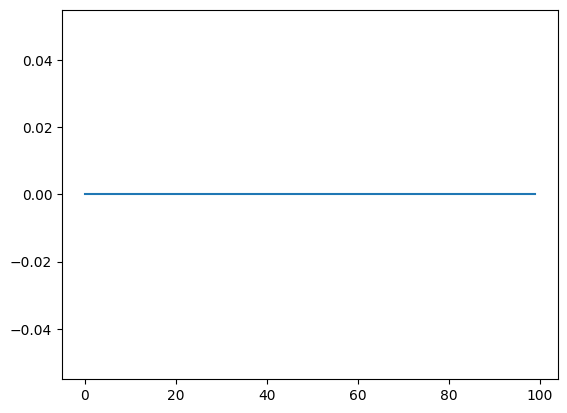

In [20]:
import matplotlib.pyplot as plt
plt.plot(mylosses)

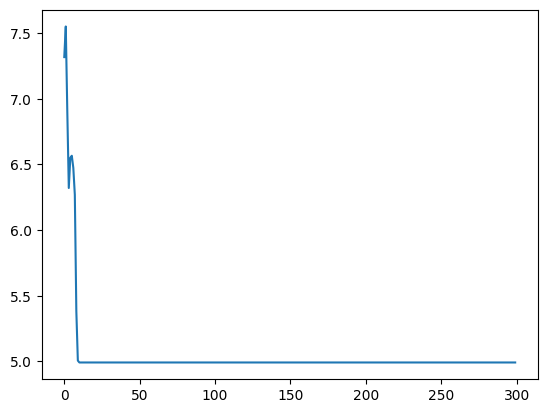

In [23]:
plt.plot(truelosses)

In [24]:
Xtest, Ytest = getdata(n)

In [25]:
Ystar = fstar(Xtest)

In [26]:
optcost = np.sum([np.dot(Ytest[i], solmap(Ystar[i])) for i in range(n)]) / n

In [275]:
f(Xtest[i], mytheta)

array([-9.48372239e+00,  9.37435322e+00, -2.27377552e+00,  8.28122641e-02,
        1.00660712e+01, -2.02557109e+01,  8.10904168e+00,  1.35385990e+00,
        3.55200364e-01,  1.11668171e+01, -3.57754310e+01, -5.00718602e+01,
       -6.22909501e-01,  1.13032128e+00,  2.49317034e+01,  1.91276528e+01,
       -4.64548815e+01, -1.70947342e+00,  2.17197440e+00,  4.67364018e+01,
        2.59350177e+02,  1.04356470e+01, -5.27483837e+00, -1.63824538e+01,
       -1.92047835e+02,  1.99213534e+02,  8.67849073e+00, -2.66429679e+00,
       -1.64462626e+01, -2.28716418e+01, -1.30531721e+01,  1.50615315e-02,
       -5.56656557e-01, -1.84446819e+02,  1.88551005e+02, -3.15710092e+00,
       -7.58568956e-01, -1.30786278e-01, -1.83741063e+02,  5.81996815e+00])

In [27]:
mycost = np.sum([np.dot(Ytest[i], solmap(f(Xtest[i], mytheta))) for i in range(n)]) / n

In [277]:
mytheta

array([[ 2.60494960e+00,  1.70783590e+00, -1.12440815e+00,
        -1.45566442e-01, -1.96060308e+00, -1.05517538e+00,
        -2.60296597e-02,  6.34658169e-01,  5.20969709e-01,
        -4.50195914e+00,  2.87437193e+00, -1.14212779e+00,
         9.42455123e-02,  3.25033913e+00, -8.18548859e+00,
         2.21636805e+00,  7.30891609e-01, -2.15662213e-01,
         3.69600385e+00,  3.57289329e+00,  4.28122978e+00,
        -3.10565390e+00, -1.09607415e+00, -7.90760962e+00,
         1.74051024e+00,  7.44309382e+00, -4.41306647e+00,
         7.07131010e-01, -6.74003055e+00, -5.29842900e+00,
         5.65251934e-01,  6.10980066e-01,  1.21321145e-01,
         6.53280573e-01,  2.45232606e+00, -4.08089289e+00,
        -4.17211610e-01,  1.43744252e+00,  3.18326543e+00,
         5.54989981e+00],
       [ 5.19820834e+00, -3.50096717e+00,  7.62973474e-01,
         3.24781084e-01, -4.24809252e+00,  8.28741739e+00,
        -3.16097341e+00,  1.83723897e-01, -6.54879958e-02,
        -1.00599687e+01,  1.67

In [278]:
f(Xtest[10], mytheta)

array([-1.81074585e+01,  9.91215359e+01, -3.55702671e+00,  1.77509696e-01,
        1.99027832e+01, -1.20033172e+02,  9.96230014e+01,  2.15135062e+00,
       -3.01402376e-01,  2.66189043e+01,  1.91505625e+02, -7.26074540e+01,
        1.51680923e+00, -1.20125113e+01, -2.81738303e+02,  3.65518280e+02,
       -7.55747064e+01,  2.06753122e+00, -1.24581415e+00, -2.34187274e+02,
        9.01286228e+02,  7.73438066e+01, -6.51052150e+00, -4.76999931e+01,
       -7.69647286e+02,  7.52711902e+02,  7.91274416e+01, -8.87232854e+00,
       -5.12863214e+01, -3.59972454e-01, -2.49603231e+01,  2.54495847e+00,
       -5.34823812e+00, -8.28260537e+02,  7.76765809e+02,  4.75346553e+01,
        3.58683902e+00, -4.39494305e+00, -8.27017686e+02, -4.73158923e+01])

In [279]:
Ystar[10]

array([2.49827636, 3.25265588, 4.17923303, 3.93203992, 2.48122874,
       1.75575911, 4.26851331, 2.53458568, 2.55564298, 2.13055377,
       1.92381249, 1.70647881, 3.25515443, 2.59631489, 0.52675191,
       2.95403114, 2.85742298, 2.52868843, 2.95509668, 3.84550158,
       2.36708497, 1.89752753, 1.88699282, 1.68073992, 1.38330959,
       3.15030331, 2.16834304, 2.70379611, 2.14750716, 1.56970096,
       3.49607292, 1.64096717, 3.03845625, 2.64193716, 2.70402976,
       3.00484901, 2.08442188, 4.86291943, 3.94575139, 3.37178058])

In [280]:
mycost

np.float64(25.8059099686753)

In [179]:
mycost2 = np.sum([np.dot(Ytest[i], solmap(f(Xtest[i], mytheta2))) for i in range(n)]) / n

In [28]:
(mycost - optcost) / optcost

np.float64(0.2918382141238003)

In [182]:
hs = [0.001, 0.01, 0.01, 1, 10, 100, 1000]
lrs = [0.001, 0.01, 0.01, 1, 10, 100, 1000]

for h in hs:
    for l in lrs:
        mytheta, mylosses, truelosses = stochastic_gradient_descent(X, Z, C, h = h, lr=l, epochs=100)
        mycost = np.sum([np.dot(Ytest[i], solmap(f(Xtest[i], mytheta))) for i in range(n)]) / n
        print(f'h={h}, lr={l}, regret ratio={(mycost - optcost) / optcost}')

  0%|          | 0/100 [00:00<?, ?it/s]

h=0.001, lr=0.001, regret ratio=0.3630749202153786


  0%|          | 0/100 [00:00<?, ?it/s]

h=0.001, lr=0.01, regret ratio=0.3714588746478419


  0%|          | 0/100 [00:00<?, ?it/s]

...

h=1000, lr=10, regret ratio=0.36902623453926897


  0%|          | 0/100 [00:00<?, ?it/s]

h=1000, lr=100, regret ratio=0.35428546986456694


  0%|          | 0/100 [00:00<?, ?it/s]

h=1000, lr=1000, regret ratio=0.361267828563074


In [120]:
h = .05
l = 0.05

mytheta, mylosses, truelosses = stochastic_gradient_descent(X, Z, C, h = h, lr=0.0005, epochs=500)
mycost = np.sum([np.dot(Ytest[i], solmap(f(Xtest[i], mytheta))) for i in range(n)]) / n
print(f'h={h}, lr={l}, regret ratio={(mycost - optcost) / optcost}')

  0%|          | 0/500 [00:00<?, ?it/s]

h=0.05, lr=0.05, regret ratio=0.33109677216624644


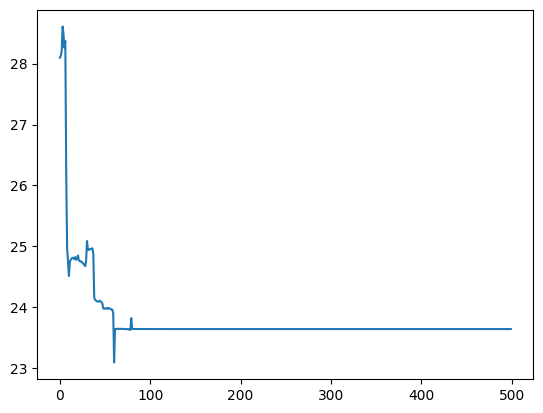

In [121]:
plt.plot(mylosses)